In [1]:
import os
import sys
import numpy as np
import pandas as pd
from pathlib import Path
import scipy.signal as signal
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import importlib
from fileorganize import dir_to_df
from sklearn.linear_model import LogisticRegression

cwd = os.getcwd()
sys.path.insert(0, os.path.abspath(os.path.dirname(cwd)))

import phonlab as phon

importlib.reload(phon)

print(phon.__name__,phon.__version__)


phonlab 0.0.55


In [2]:
mandarin = Path(
    '/Volumes/WDBook/Corpora/asc/corpus'
)

# get a dataframe listing all of the TextGrid files in the database
tgdf = dir_to_df(mandarin, fnpat=r"(?P<gender>[mf]).+.TextGrid$", addcols=['barename'])
print(f'Found {len(tgdf)} TextGrid files.')

tgdf

Found 780 TextGrid files.


,relpath,fname,barename,gender
0,f001,f001001_01.TextGrid,f001001_01,f
1,f001,f001001_02.TextGrid,f001001_02,f
2,f001,f001001_03.TextGrid,f001001_03,f
3,f001,f001001_04.TextGrid,f001001_04,f
4,f001,f001001_05.TextGrid,f001001_05,f
...,...,...,...,...
775,m005,m005017_06.TextGrid,m005017_06,m
776,m005,m005018_01.TextGrid,m005018_01,m
777,m005,m005018_02.TextGrid,m005018_02,m
778,m005,m005018_03.TextGrid,m005018_03,m


In [3]:
speaker=""
rng = np.random.default_rng()

bigdf = pd.DataFrame()

for row in tgdf.itertuples():   # loop through all of the label files
    if rng.random()<0.75:  # to speed things up we'll just take 25% of the corpus
        continue           # this is still over a million frames of data
    
    if speaker != row.relpath:
        speaker = row.relpath
        print(f"{speaker}")   


    wav = f'{row.barename}.wav'
    wavname = str(mandarin / row.relpath / wav)  # construct the name of the wav file

    if row.gender == 'm':
        f0_range = [60,400]
    else:
        f0_range = [60,400]

    audio,egg,fs = phon.loadsig(wavname, chansel=[0,1])
    f0df = phon.get_f0_acd(audio,fs,prom=11,f0_range=f0_range)
    eggdf = phon.egg_to_oq(egg,fs,f0_range=f0_range)
    f0df['vuv'] = 'uv'
    f0df['vuv'] = f0df['vuv'].where(np.isnan(eggdf.OQ), 'v')
    f0df['file'] = wav

    if bigdf.empty:
        bigdf = f0df
    else:
        bigdf = pd.concat([bigdf,f0df],ignore_index=True)


bigdf.head()

f001
f002
f003
f004
f005
m001
m002
m003
m004
m005


,sec,f0,rms,h1h2,C,probv,voiced,vuv,file
0,0.025,NaN,-76.081289,NaN,9.0,0.006328,False,uv,f001001_02.wav
1,0.030,NaN,-76.210400,NaN,9.0,0.006194,False,uv,f001001_02.wav
2,0.035,NaN,-76.270552,NaN,9.0,0.006133,False,uv,f001001_02.wav
3,0.040,NaN,-76.213020,NaN,9.0,0.006192,False,uv,f001001_02.wav
4,0.045,NaN,-76.018171,NaN,9.0,0.006394,False,uv,f001001_02.wav


In [4]:
print(f"N = {len(bigdf)}")
print(bigdf.groupby('vuv').C.mean())
print(bigdf.groupby('vuv').rms.mean())
print(bigdf.groupby('vuv').h1h2.mean())

print(pd.crosstab(bigdf.voiced,bigdf.vuv))

# take 10000 samples of voiced, and 10000 of voiceless - for figure
test_data = bigdf.groupby('vuv').sample(10000,replace=True)
test_data.head()

print(pd.crosstab(test_data.voiced,test_data.vuv))

N = 1117937
vuv
uv    7.136526
v     3.254551
Name: C, dtype: float64
vuv
uv   -63.868708
v    -38.698186
Name: rms, dtype: float64
vuv
uv   -1.156534
v    -1.489288
Name: h1h2, dtype: float64
vuv         uv       v
voiced                
False   598765   33298
True    145047  340827
vuv       uv     v
voiced            
False   8011   856
True    1989  9144


<Axes: xlabel='C', ylabel='rms'>

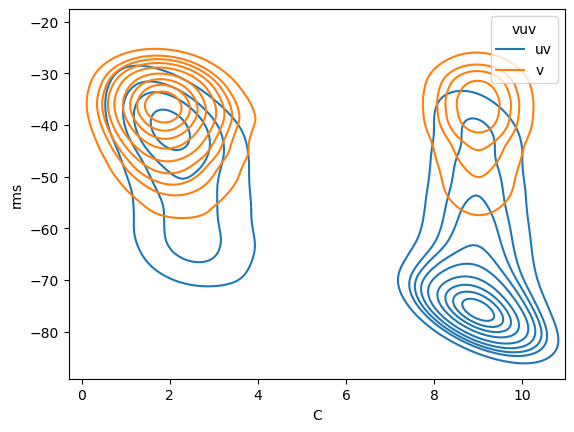

In [5]:
sns.kdeplot(test_data,y='rms',x="C",hue=("vuv"))

In [16]:
def warn(*args, **kwargs):   # this is a hack to avoid getting so many printed warning messages
    pass
warnings.warn = warn

# select a test set randomly - no priors, each phone is equally likely
test_data = bigdf.groupby('vuv').sample(20000,replace=True)

X = test_data[['rms','C']].to_numpy()
lm = LogisticRegression(class_weight='balanced').fit(X,test_data["vuv"])
score = lm.score(X,test_data['vuv'])

print(score)
#print(f"model is:  {lm.intercept_[0]:3.2f} + {lm.coef_[0,0]:3.3f}*rms + {lm.coef_[0,1]:3.3f}*C + {lm.coef_[0,2]:3.3f}*h1h2")
print(f"model is:  {lm.intercept_[0]:3.2f} + {lm.coef_[0,0]:3.3f}*rms + {lm.coef_[0,1]:3.3f}*C")

predicted = lm.predict(X)
print(pd.crosstab(predicted,test_data.vuv,normalize='columns'))

0.859875
model is:  8.34 + 0.167*rms + -0.072*C
vuv         uv      v
row_0                
uv     0.80275  0.083
v      0.19725  0.917
